zip-unzip

In [1]:
!unzip mini_image_captioning_dataset.zip

Archive:  mini_image_captioning_dataset.zip
  inflating: image_captioning_dataset/captions.txt  
  inflating: image_captioning_dataset/README_dataset.txt  
  inflating: image_captioning_dataset/images/red_ball.jpg  
  inflating: image_captioning_dataset/images/blue_ball.jpg  
  inflating: image_captioning_dataset/images/green_tree.jpg  
  inflating: image_captioning_dataset/images/small_house.jpg  
  inflating: image_captioning_dataset/images/yellow_sun.jpg  
  inflating: image_captioning_dataset/images/brown_dog.jpg  
  inflating: image_captioning_dataset/images/white_cat.jpg  
  inflating: image_captioning_dataset/images/red_car.jpg  
  inflating: image_captioning_dataset/images/blue_car.jpg  
  inflating: image_captioning_dataset/images/orange_flower.jpg  
  inflating: image_captioning_dataset/images/green_leaf.jpg  
  inflating: image_captioning_dataset/images/black_bird.jpg  


dataset check

In [2]:
!ls image_captioning_dataset
!ls image_captioning_dataset/images

captions.txt  images  README_dataset.txt
black_bird.jpg	brown_dog.jpg	orange_flower.jpg  small_house.jpg
blue_ball.jpg	green_leaf.jpg	red_ball.jpg	   white_cat.jpg
blue_car.jpg	green_tree.jpg	red_car.jpg	   yellow_sun.jpg


cnn code

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Add, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Dataset path
data_path = "image_captioning_dataset"
image_folder = data_path + "/images"
caption_file = data_path + "/captions.txt"

# Load captions
captions = pd.read_csv(caption_file)
captions.head()

,image,caption
0,red_ball.jpg,a red ball on the floor
1,blue_ball.jpg,a blue ball on the floor
2,green_tree.jpg,a green tree near the house
3,small_house.jpg,a small house under the sky
4,yellow_sun.jpg,a yellow sun in the sky


caption preprocessing

In [4]:
captions["caption"] = "startseq " + captions["caption"] + " endseq"

tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions["caption"])

vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in captions["caption"])

print("Vocabulary Size:", vocab_size)
print("Maximum Caption Length:", max_length)

Vocabulary Size: 39
Maximum Caption Length: 9


cnn full extraction

In [5]:
cnn_model = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")
cnn_model.trainable = False

features = {}

for img_name in captions["image"]:
    img_path = os.path.join(image_folder, img_name)

    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    feature = cnn_model.predict(img_array, verbose=0)
    features[img_name] = feature[0]

print("Image features extracted successfully")

/tmp/ipykernel_896/1571870749.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  cnn_model = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Image features extracted successfully


training data prepare

In [6]:
X_image = []
X_text = []
y_output = []

for index, row in captions.iterrows():
    img_name = row["image"]
    caption = row["caption"]

    seq = tokenizer.texts_to_sequences([caption])[0]

    for i in range(1, len(seq)):
        input_seq = seq[:i]
        output_word = seq[i]

        input_seq = pad_sequences([input_seq], maxlen=max_length)[0]
        output_word = tf.keras.utils.to_categorical(
            [output_word], num_classes=vocab_size
        )[0]

        X_image.append(features[img_name])
        X_text.append(input_seq)
        y_output.append(output_word)

X_image = np.array(X_image)
X_text = np.array(X_text)
y_output = np.array(y_output)

print("Training data ready")
print(X_image.shape)
print(X_text.shape)
print(y_output.shape)

Training data ready
(85, 1280)
(85, 9)
(85, 39)


cnn + lstm model

In [7]:
# Image feature input
image_input = Input(shape=(1280,))
image_features = Dropout(0.3)(image_input)
image_features = Dense(256, activation="relu")(image_features)

# Text input
text_input = Input(shape=(max_length,))
text_features = Embedding(vocab_size, 256, mask_zero=True)(text_input)
text_features = LSTM(256)(text_features)

# Combine CNN + LSTM
decoder = Add()([image_features, text_features])
decoder = Dense(256, activation="relu")(decoder)
output = Dense(vocab_size, activation="softmax")(decoder)

model = Model(inputs=[image_input, text_input], outputs=output)

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam"
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1280)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 9, 256)    │      9,984 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 9)         │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    327,936 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 39)        │     10,023 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 939,047 (3.58 MB)

 Trainable params: 939,047 (3.58 MB)

 Non-trainable params: 0 (0.00 B)

train model

In [8]:
model.fit(
    [X_image, X_text],
    y_output,
    epochs=60,
    batch_size=4
)

Epoch 1/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 4.1389
Epoch 2/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 3.1980
Epoch 3/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 2.6549
Epoch 4/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 2.1672
Epoch 5/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 1.6198
Epoch 6/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 1.3542
Epoch 7/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.9873
Epoch 8/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.7909
Epoch 9/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.5457
Epoch 10/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.4571
Epoch 11/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.4166
Epoch 12/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.2762
Epoch 13/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1809
Epoch 14/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.2098
Epoch 15/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1218
Epoc

caption generate function

In [9]:
def generate_caption(image_name):
    in_text = "startseq"

    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)

        prediction = model.predict(
            [features[image_name].reshape(1, 1280), sequence],
            verbose=0
        )

        word_index = np.argmax(prediction)
        word = tokenizer.index_word.get(word_index)

        if word is None:
            break

        in_text += " " + word

        if word == "endseq":
            break

    final_caption = in_text.replace("startseq", "").replace("endseq", "").strip()
    return final_caption

one image output

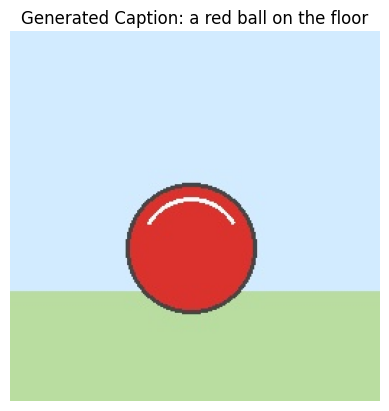

Image Name: red_ball.jpg
Generated Caption: a red ball on the floor


In [10]:
test_image = captions["image"].iloc[0]

generated_caption = generate_caption(test_image)

img = load_img(os.path.join(image_folder, test_image))

plt.imshow(img)
plt.axis("off")
plt.title("Generated Caption: " + generated_caption)
plt.show()

print("Image Name:", test_image)
print("Generated Caption:", generated_caption)